In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo


breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

print(breast_cancer_wisconsin_diagnostic.metadata)

print(breast_cancer_wisconsin_diagnostic.variables)


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [ ]:
# Train–Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_recall_curve

In [ ]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

In [ ]:
y_pred = nb_model.predict(X_test)
y_prob = nb_model.predict_proba(X_test)[:,1]

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[90  0]
 [ 8 45]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           B       0.92      1.00      0.96        90
           M       1.00      0.85      0.92        53

    accuracy                           0.94       143
   macro avg       0.96      0.92      0.94       143
weighted avg       0.95      0.94      0.94       143



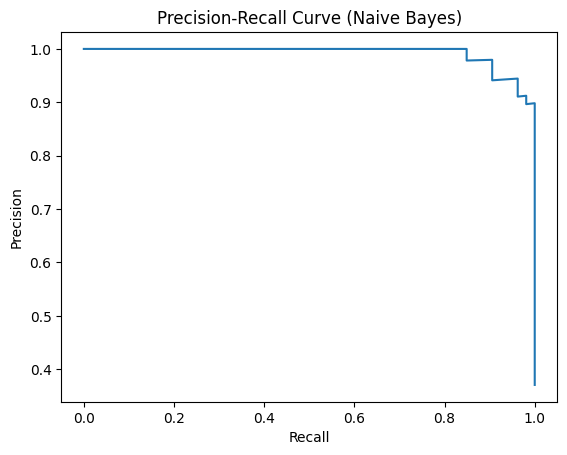

In [ ]:
y_test_numeric = y_test['Diagnosis'].map({'M': 1, 'B': 0})
precision, recall, thresholds = precision_recall_curve(y_test_numeric, y_prob, pos_label=1)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Naive Bayes)")
plt.show()

Experiment - 2

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import precision_recall_curve

In [ ]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [ ]:
acc_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.8951048951048951


In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Confusion Matrix:")
print(cm_dt)

Confusion Matrix:
[[89  1]
 [14 39]]


In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           B       0.86      0.99      0.92        90
           M       0.97      0.74      0.84        53

    accuracy                           0.90       143
   macro avg       0.92      0.86      0.88       143
weighted avg       0.91      0.90      0.89       143



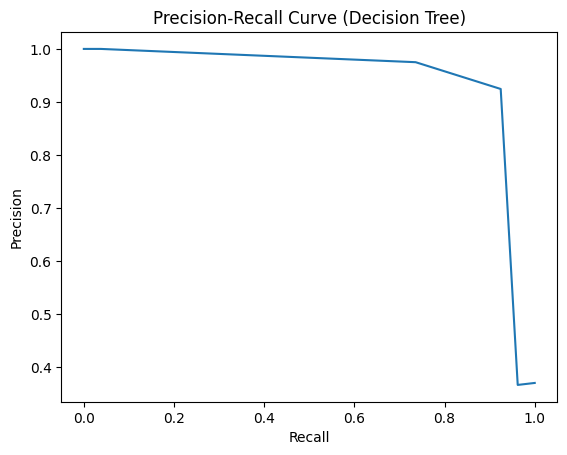

In [ ]:
y_test_numeric_dt = y_test['Diagnosis'].map({'M': 1, 'B': 0})
precision_dt, recall_dt, thresholds_dt = precision_recall_curve(y_test_numeric_dt, y_prob_dt, pos_label=1)

plt.figure()
plt.plot(recall_dt, precision_dt)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Decision Tree)")
plt.show()

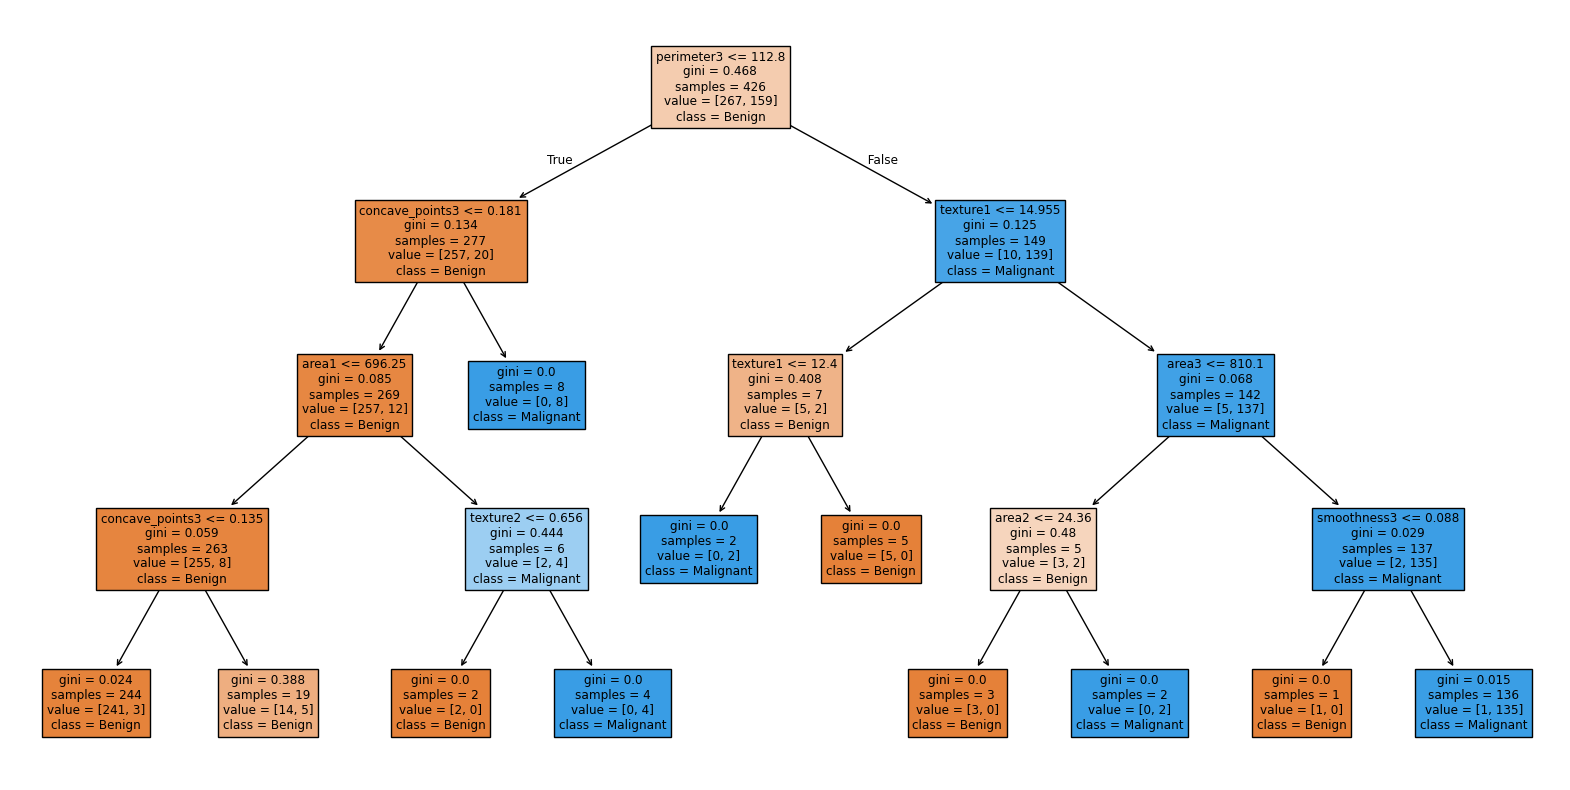

In [ ]:
 plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Benign','Malignant'],
    filled=True
)

plt.show()

Experiment - 3

In [ ]:
nb_train_acc = accuracy_score(y_train, nb_model.predict(X_train))
nb_test_acc = accuracy_score(y_test, nb_model.predict(X_test))

dt_train_acc = accuracy_score(y_train, dt_model.predict(X_train))
dt_test_acc = accuracy_score(y_test, dt_model.predict(X_test))

print("Naive Bayes Train Accuracy:", nb_train_acc)
print("Naive Bayes Test Accuracy:", nb_test_acc)

print("Decision Tree Train Accuracy:", dt_train_acc)
print("Decision Tree Test Accuracy:", dt_test_acc)

Naive Bayes Train Accuracy: 0.9483568075117371
Naive Bayes Test Accuracy: 0.9440559440559441
Decision Tree Train Accuracy: 0.9788732394366197
Decision Tree Test Accuracy: 0.8951048951048951


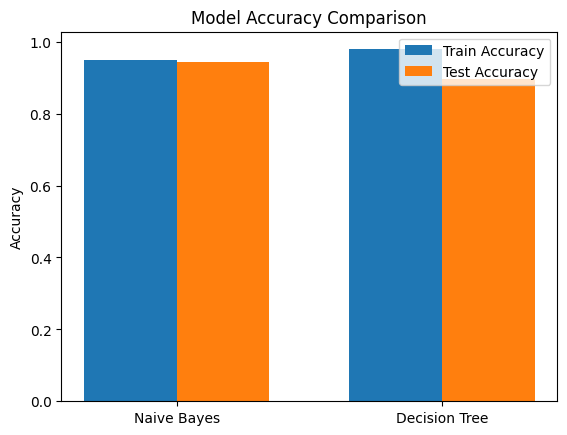

In [ ]:
models = ['Naive Bayes', 'Decision Tree']
train_scores = [nb_train_acc, dt_train_acc]
test_scores = [nb_test_acc, dt_test_acc]

x = np.arange(len(models))
width = 0.35

plt.figure()
plt.bar(x - width/2, train_scores, width, label='Train Accuracy')
plt.bar(x + width/2, test_scores, width, label='Test Accuracy')

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

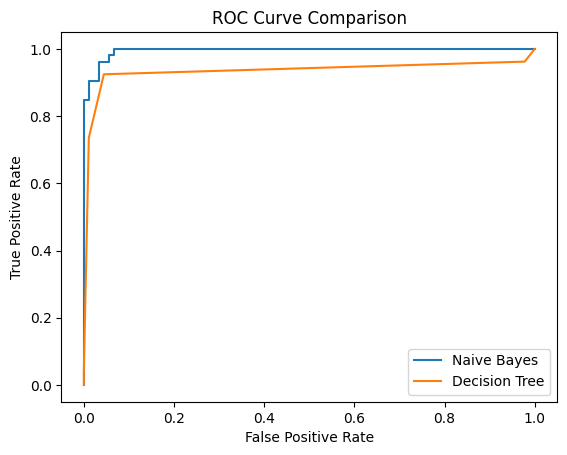

In [ ]:
nb_prob = nb_model.predict_proba(X_test)[:,1]
dt_prob = dt_model.predict_proba(X_test)[:,1]

# Ensure y_test_numeric is defined for roc_curve
# y_test_numeric was previously defined for precision_recall_curve, so we can reuse it.
# If it wasn't, we would add: y_test_numeric = y_test['Diagnosis'].map({'M': 1, 'B': 0})

fpr_nb, tpr_nb, _ = roc_curve(y_test_numeric, nb_prob, pos_label=1)
fpr_dt, tpr_dt, _ = roc_curve(y_test_numeric, dt_prob, pos_label=1)

plt.figure()
plt.plot(fpr_nb, tpr_nb, label="Naive Bayes")
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
import seaborn as sns

In [ ]:
cm_nb = confusion_matrix(y_test, nb_model.predict(X_test))
cm_dt = confusion_matrix(y_test, dt_model.predict(X_test))

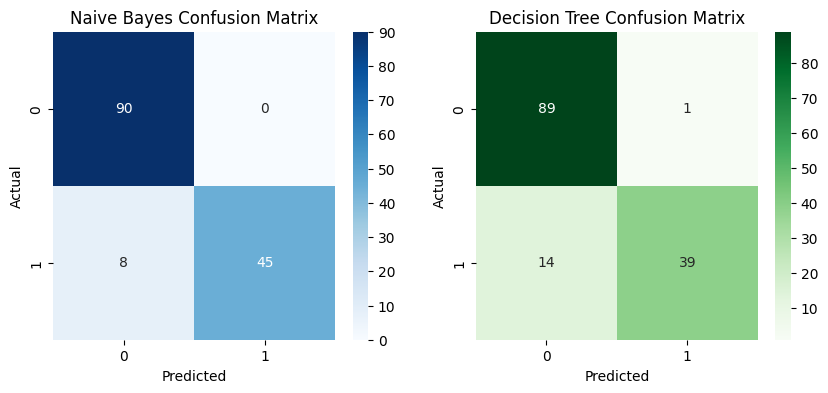

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1,2,2)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()